# 01 — Data Exploration

**Question this notebook answers:** what is actually in our StatsBomb development
subset, and what does it imply for feature engineering, statistics and validation
in the tasks that follow?

Nothing is modelled here. The purpose is to establish, from the data itself:

- what entities exist (competitions, matches, teams, players, events, shots);
- how the shot outcome is distributed (the future prediction target);
- which fields are present, absent, or absent-by-design;
- what the pitch coordinate system is, verified rather than assumed;
- which structural properties (clustering, heterogeneity, leakage traps) will
  constrain later modelling.

**Data source.** [StatsBomb Open Data](https://github.com/statsbomb/open-data),
acquired with `make data` and read through `football_intelligence.data.statsbomb`.
Loading logic is *not* reimplemented here. Data is provided by StatsBomb under the
StatsBomb Open Data User Agreement.

**Scope note — geometry is deferred.** Shot distance and angle are *derived*
features that need a documented formula, explicit coordinate assumptions and unit
tests. That is task T05, so this notebook deliberately works with **raw
coordinates only** and reports goal rate by coordinate band rather than by an
undefined "distance". Defining geometry twice — once informally here, once
properly in `src/` — is exactly the duplication the project rules warn against.

## 0. Setup

The notebook resolves the repository root so it can be run from anywhere, then
reads everything through the ingestion layer built in T02.

In [1]:
import collections
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.axes import Axes

from football_intelligence.data import statsbomb as sb


def find_repository_root(start: Path) -> Path:
    """Walk upwards until the directory containing pyproject.toml is found."""
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError(f"No pyproject.toml above {start}")


REPO_ROOT = find_repository_root(Path.cwd())
RAW_ROOT = REPO_ROOT / "data" / "raw" / "statsbomb"

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.facecolor"] = "white"

print(f"repository root: {REPO_ROOT}")
print(f"raw StatsBomb data: {RAW_ROOT} (exists: {RAW_ROOT.exists()})")

repository root: /home/tom/projects/football-intelligence-lab
raw StatsBomb data: /home/tom/projects/football-intelligence-lab/data/raw/statsbomb (exists: True)


## 1. Competitions and seasons

**Inspecting:** what StatsBomb publishes in total, and which competition seasons
our development subset actually contains on disk.

In [2]:
catalogue = pd.DataFrame(
    [
        {
            "competition_id": season.competition_id,
            "season_id": season.season_id,
            "competition": season.competition_name,
            "season": season.season_name,
            "gender": season.competition_gender,
        }
        for season in sb.competition_seasons(sb.load_competitions(RAW_ROOT))
    ]
)

print(f"competition seasons published by StatsBomb: {len(catalogue)}")
print(f"distinct competitions: {catalogue['competition_id'].nunique()}")
print(f"gender split: {catalogue['gender'].value_counts().to_dict()}")

SUBSET = sb.DEFAULT_DEVELOPMENT_SUBSET
print("\nOur development subset:")
for season in SUBSET:
    print(f"  {season}")

competition seasons published by StatsBomb: 80
distinct competitions: 24
gender split: {'male': 67, 'female': 13}

Our development subset:
  43/3 (FIFA World Cup 2018)
  55/43 (UEFA Euro 2020)


**Learned.** StatsBomb publishes 80 competition seasons; we deliberately hold two
of them locally. The subset is two *men's international tournaments* — FIFA World
Cup 2018 and UEFA Euro 2020 — chosen in T02 to be large enough for modelling while
staying at a few percent of the full repository.

**Implication.** Competition is a plausible grouping/stratification variable but
not a rich one: with only two levels, both men's tournaments, we cannot study
league or gender effects. Any claim this project makes generalises to
international tournament football, not to football in general.

## 2. Matches

**Inspecting:** match counts, date ranges, competition stages and scorelines.

In [3]:
match_frames = []
for season in SUBSET:
    records = sb.load_matches(season.competition_id, season.season_id, RAW_ROOT)
    frame = pd.json_normalize(records)
    frame["competition_label"] = f"{season.competition_name} {season.season_name}"
    match_frames.append(frame)

matches = pd.concat(match_frames, ignore_index=True)
matches["match_date"] = pd.to_datetime(matches["match_date"])
matches["total_goals"] = matches["home_score"] + matches["away_score"]

print(f"matches: {len(matches)}")
print(f"columns: {len(matches.columns)}")
matches.groupby("competition_label").agg(
    matches=("match_id", "count"),
    first_match=("match_date", "min"),
    last_match=("match_date", "max"),
    goals=("total_goals", "sum"),
    goals_per_match=("total_goals", "mean"),
).round(2)

matches: 115
columns: 44


/tmp/ipykernel_27794/1904388803.py:20: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ).round(2)


,matches,first_match,last_match,goals,goals_per_match
competition_label,,,,,
FIFA World Cup 2018,64,2018-06-14,2018-07-15,169,2.64
UEFA Euro 2020,51,2021-06-11,2021-07-11,142,2.78


In [4]:
stage_counts = (
    matches.groupby(["competition_label", "competition_stage.name"])
    .size()
    .rename("matches")
    .reset_index()
    .sort_values(["competition_label", "matches"], ascending=[True, False])
)
display(stage_counts)

tournament_goals = int(matches["total_goals"].sum())
print(f"\ntotal goals recorded in match metadata: {tournament_goals}")
print(f"mean goals per match: {tournament_goals / len(matches):.2f}")

,competition_label,competition_stage.name,matches
2,FIFA World Cup 2018,Group Stage,48
4,FIFA World Cup 2018,Round of 16,8
3,FIFA World Cup 2018,Quarter-finals,4
5,FIFA World Cup 2018,Semi-finals,2
0,FIFA World Cup 2018,3rd Place Final,1
1,FIFA World Cup 2018,Final,1
7,UEFA Euro 2020,Group Stage,36
9,UEFA Euro 2020,Round of 16,8
8,UEFA Euro 2020,Quarter-finals,4
10,UEFA Euro 2020,Semi-finals,2



total goals recorded in match metadata: 311
mean goals per match: 2.70


**Learned.** 115 matches: 64 (World Cup 2018) plus 51 (Euro 2020), spanning the
group stage through the final. 311 goals in total, ~2.7 per match, which is
typical for tournament football.

**Implication.** Knockout matches can go to extra time and penalty shootouts —
both appear in the event data and are examined in §7. Competition stage is also a
selection effect: knockout matches involve stronger teams, so pooling stages
assumes shot quality is comparable across them.

## 3. Teams

**Inspecting:** how many teams there are and how many matches each played.

In [5]:
team_appearances = pd.concat(
    [
        matches[["competition_label", "home_team.home_team_name"]].rename(
            columns={"home_team.home_team_name": "team"}
        ),
        matches[["competition_label", "away_team.away_team_name"]].rename(
            columns={"away_team.away_team_name": "team"}
        ),
    ]
)

per_team = team_appearances.groupby(["competition_label", "team"]).size().rename("matches")
print(f"distinct teams: {team_appearances['team'].nunique()}")
print(per_team.groupby("competition_label").agg(["count", "min", "max", "mean"]).round(2))
print("\nmost matches played:")
print(per_team.sort_values(ascending=False).head(5))

distinct teams: 44
                     count  min  max  mean
competition_label                         
FIFA World Cup 2018     32    3    7  4.00
UEFA Euro 2020          24    3    7  4.25

most matches played:
competition_label    team   
FIFA World Cup 2018  Belgium    7
                     Croatia    7
                     France     7
                     England    7
UEFA Euro 2020       Italy      7
Name: matches, dtype: int64


**Learned.** 44 distinct national teams — 32 at the World Cup and 24 at the Euro,
with 12 appearing in both — each playing between 3 and 7 matches per tournament.

**Implication.** Team is a small-sample grouping factor: 3–7 matches per team is
far too few to estimate a stable team effect independently, which is an argument
for partial pooling (T28/T29) rather than fixed effects per team. The 12 teams
present in both tournaments are also the only ones for which a cross-competition
comparison is even possible.

## 4. Players

**Inspecting:** squad sizes and how many matches each player appears in, read
from the lineup files.

In [6]:
lineup_rows = []
for _, match in matches.iterrows():
    for team in sb.load_lineups(int(match["match_id"]), RAW_ROOT):
        for player in team["lineup"]:
            lineup_rows.append(
                {
                    "match_id": int(match["match_id"]),
                    "competition_label": match["competition_label"],
                    "team": team["team_name"],
                    "player_id": player["player_id"],
                    "player": player.get("player_nickname") or player["player_name"],
                    "positions": len(player.get("positions", [])),
                }
            )

lineups = pd.DataFrame(lineup_rows)
appearances = lineups.groupby("player_id").size().rename("squad_listings")

print(f"player-match squad listings: {len(lineups)}")
print(f"distinct players: {lineups['player_id'].nunique()}")
print(f"\nsquad listings per player:\n{appearances.describe().round(2)}")
print(
    "\nplayers never actually on the pitch (no recorded position): "
    f"{int((lineups['positions'] == 0).groupby(lineups['player_id']).all().sum())}"
)

player-match squad listings: 5231
distinct players: 1199

squad listings per player:
count    1199.00
mean        4.36
std         2.34
min         1.00
25%         3.00
50%         4.00
75%         5.00
max        14.00
Name: squad_listings, dtype: float64

players never actually on the pitch (no recorded position): 226


**Learned.** 1,199 distinct players and 5,231 player-match squad listings. A lineup
file lists the whole matchday squad, so a listing is *not* an appearance: **226
players never took the pitch at all** (no recorded position in any match). The
median player is listed in 4 squads; the maximum is 14, reached by players who
featured in both tournaments.

**Implication.** Player identity is the key clustering variable for T27–T31, but a
single tournament caps exposure at 7 matches. Player-level effects will be weakly
identified for most players, which is precisely the motivation for hierarchical
shrinkage rather than per-player point estimates. Squad listings must not be used
as an exposure denominator — minutes or shots are the honest measure.

## 5. Event types — one streaming pass

**Inspecting:** the full event stream. All 115 matches are read once; we keep only
the aggregates and the shot rows, never all 420k events at the same time. The same
pass collects the coordinate extremes used in §8.

The shot table built here is **exploratory**. The production shot dataset, with
documented derived features, is task T05 (`features/shots.py`).

In [7]:
SHOT_FLAGS = (
    "first_time",
    "one_on_one",
    "open_goal",
    "deflected",
    "aerial_won",
    "follows_dribble",
    "redirect",
)


def shot_record(event: sb.JSONObject, match: pd.Series) -> dict[str, Any]:
    """Flatten one StatsBomb shot event into a flat row (exploration only)."""
    shot = event["shot"]
    location = event.get("location") or [np.nan, np.nan]
    end_location = shot.get("end_location") or []
    record: dict[str, Any] = {
        "match_id": int(match["match_id"]),
        "competition_label": match["competition_label"],
        "stage": match["competition_stage.name"],
        "period": event.get("period"),
        "minute": event.get("minute"),
        "team": event["team"]["name"],
        "player_id": event.get("player", {}).get("id"),
        "player": event.get("player", {}).get("name"),
        "position": event.get("position", {}).get("name"),
        "play_pattern": event.get("play_pattern", {}).get("name"),
        "x": location[0],
        "y": location[1],
        "end_x": end_location[0] if len(end_location) > 0 else np.nan,
        "end_y": end_location[1] if len(end_location) > 1 else np.nan,
        "end_z": end_location[2] if len(end_location) > 2 else np.nan,
        "outcome": shot["outcome"]["name"],
        "shot_type": shot["type"]["name"],
        "body_part": shot.get("body_part", {}).get("name"),
        "technique": shot.get("technique", {}).get("name"),
        "statsbomb_xg": shot.get("statsbomb_xg"),
        "has_freeze_frame": "freeze_frame" in shot,
        "has_key_pass": "key_pass_id" in shot,
        # StatsBomb omits these booleans entirely when false (see section 6).
        "under_pressure": event.get("under_pressure", False),
    }
    for flag in SHOT_FLAGS:
        record[flag] = shot.get(flag, False)
    record["is_goal"] = record["outcome"] == "Goal"
    return record


event_type_counts: collections.Counter[str] = collections.Counter()
own_goal_events: collections.Counter[str] = collections.Counter()
located_events = 0
total_events = 0
coordinate_extremes = {"x_min": np.inf, "x_max": -np.inf, "y_min": np.inf, "y_max": -np.inf}
shot_rows: list[dict[str, Any]] = []

for _, match in matches.iterrows():
    events = sb.load_events(int(match["match_id"]), RAW_ROOT)
    total_events += len(events)
    for event in events:
        name = event.get("type", {}).get("name", "<missing type>")
        event_type_counts[name] += 1
        if name in ("Own Goal Against", "Own Goal For"):
            own_goal_events[name] += 1
        location = event.get("location")
        if isinstance(location, list) and len(location) >= 2:
            located_events += 1
            coordinate_extremes["x_min"] = min(coordinate_extremes["x_min"], location[0])
            coordinate_extremes["x_max"] = max(coordinate_extremes["x_max"], location[0])
            coordinate_extremes["y_min"] = min(coordinate_extremes["y_min"], location[1])
            coordinate_extremes["y_max"] = max(coordinate_extremes["y_max"], location[1])
    for event in sb.events_of_type(events, "Shot"):
        shot_rows.append(shot_record(event, match))

shots = pd.DataFrame(shot_rows)
print(f"events read: {total_events:,}")
print(
    f"events carrying pitch coordinates: {located_events:,} ({located_events / total_events:.1%})"
)
print(f"shots extracted: {len(shots):,}")

events read: 420,489
events carrying pitch coordinates: 415,162 (98.7%)
shots extracted: 2,995


In [8]:
event_types = (
    pd.Series(event_type_counts, name="events")
    .sort_values(ascending=False)
    .to_frame()
    .assign(share=lambda d: d["events"] / d["events"].sum())
)
event_types["share"] = (event_types["share"] * 100).round(2)
print(f"distinct event types: {len(event_types)}")
event_types.head(15)

distinct event types: 35


,events,share
Pass,117700,27.99
Ball Receipt*,111617,26.54
Carry,94322,22.43
Pressure,39419,9.37
Ball Recovery,10123,2.41
Duel,6496,1.54
Clearance,4356,1.04
Block,3930,0.93
Dribble,3585,0.85
Goal Keeper,3489,0.83


**Learned.** 420,489 events across 35 event types. The stream is dominated by
on-ball mechanics — `Pass`, `Ball Receipt*` and `Carry` together are **77%** of all
events — while `Shot` accounts for only **0.71%** (2,995 rows). 98.7% of events
carry pitch coordinates; the ones that do not are structural markers (`Starting
XI`, `Half End`, substitutions) that have no location by design.

**Implication.** The modelling unit for xG is a rare event type inside a very
large stream. Reading every event to keep 0.7% of them is wasteful, which is the
argument for the T04 Parquet/DuckDB layer: normalise once, query cheaply
afterwards.

## 6. Shot outcomes, goals and class balance

**Inspecting:** the distribution of the future prediction target.

In [9]:
outcome_summary = (
    shots["outcome"]
    .value_counts()
    .to_frame("shots")
    .assign(share=lambda d: (d["shots"] / d["shots"].sum() * 100).round(2))
)
display(outcome_summary)

print(f"shots: {len(shots):,}")
print(f"goals: {int(shots['is_goal'].sum()):,}")
print(f"overall goal rate: {shots['is_goal'].mean():.4f}")

,shots,share
outcome,,
Off T,988,32.99
Blocked,794,26.51
Saved,624,20.83
Goal,338,11.29
Wayward,185,6.18
Post,55,1.84
Saved Off Target,6,0.20
Saved to Post,5,0.17


shots: 2,995
goals: 338
overall goal rate: 0.1129


**Learned.** Eight outcome categories. `Goal` is one of them, at 11.3% of all
shots; the remainder are dominated by `Off T` (33%), `Blocked` (27%) and `Saved`
(21%).

**Implication.** The target is a *binarisation* of a richer categorical outcome.
`Blocked` is worth noting: the shot never reached the goal because a defender
intervened, which is partly a property of the defensive configuration rather than
of the shot itself. Collapsing all non-goals into one class is the standard xG
definition and we will follow it, but it is a modelling choice, not a fact.

Class balance of ~11% positives is imbalanced but not extreme. It is a strong
argument for the probabilistic metrics the project mandates (log loss, Brier,
calibration) over accuracy, and it means PR-AUC is more informative than ROC-AUC.

## 7. Periods, extra time and penalty shootouts

**Inspecting:** which periods shots come from. The StatsBomb specification defines
`period` 1–2 as the halves, 3–4 as extra time and **5 as the penalty shootout**.

In [10]:
period_summary = (
    shots.groupby("period")
    .agg(shots=("is_goal", "size"), goals=("is_goal", "sum"), goal_rate=("is_goal", "mean"))
    .assign(goal_rate=lambda d: d["goal_rate"].round(3))
)
display(period_summary)

print("shot types recorded in period 5:")
print(shots.loc[shots["period"] == 5, "shot_type"].value_counts().to_dict())

in_play = shots[shots["period"] != 5]
print(f"\nshots excluding shootouts: {len(in_play):,}")
print(f"goals excluding shootouts:  {int(in_play['is_goal'].sum()):,}")
print(f"goal rate excluding shootouts: {in_play['is_goal'].mean():.4f}")

,shots,goals,goal_rate
period,,,
1,1274,102,0.080
2,1514,176,0.116
3,61,6,0.098
4,69,4,0.058
5,77,50,0.649


shot types recorded in period 5:
{'Penalty': 77}

shots excluding shootouts: 2,918
goals excluding shootouts:  288
goal rate excluding shootouts: 0.0987


**Learned.** 77 shots sit in period 5 and **every one of them is a `Penalty`**:
these are penalty shootouts, not open play. They convert at 65%, six times the
in-play rate. Removing them leaves 2,918 shots at a **9.9%** goal rate.

**Implication — this is a correctness issue, not a cleaning preference.** Shootout
penalties are a different data-generating process, they are not part of the match
scoreline, and they are heavily over-represented in the high-conversion tail. They
must be excluded from the xG dataset (T05) and from any finishing analysis that
claims to measure in-play ability (T31). Extra-time shots (periods 3–4, 130 shots)
are ordinary play and should be kept.

## 8. Shot categories: type, body part, technique

**Inspecting:** the categorical descriptors of a shot and their empirical goal
rates. Shootout penalties are excluded from here onwards unless stated.

In [11]:
def rate_table(frame: pd.DataFrame, column: str) -> pd.DataFrame:
    """Count, goal count and empirical goal rate per category, most common first."""
    table = frame.groupby(column).agg(
        shots=("is_goal", "size"),
        goals=("is_goal", "sum"),
        goal_rate=("is_goal", "mean"),
    )
    table["goal_rate"] = table["goal_rate"].round(3)
    table["share_of_shots"] = (table["shots"] / len(frame) * 100).round(1)
    return table.sort_values("shots", ascending=False)


for column in ("shot_type", "body_part", "technique", "play_pattern"):
    print(f"--- {column} ---")
    display(rate_table(in_play, column))

--- shot_type ---


,shots,goals,goal_rate,share_of_shots
shot_type,,,,
Open Play,2749,250,0.091,94.2
Free Kick,123,7,0.057,4.2
Penalty,46,31,0.674,1.6


--- body_part ---


,shots,goals,goal_rate,share_of_shots
body_part,,,,
Right Foot,1488,139,0.093,51.0
Left Foot,881,89,0.101,30.2
Head,531,59,0.111,18.2
Other,18,1,0.056,0.6


--- technique ---


,shots,goals,goal_rate,share_of_shots
technique,,,,
Normal,2355,233,0.099,80.7
Half Volley,304,26,0.086,10.4
Volley,193,17,0.088,6.6
Diving Header,20,3,0.150,0.7
Lob,17,7,0.412,0.6
Overhead Kick,17,0,0.000,0.6
Backheel,12,2,0.167,0.4


--- play_pattern ---


,shots,goals,goal_rate,share_of_shots
play_pattern,,,,
Regular Play,1065,97,0.091,36.5
From Free Kick,543,44,0.081,18.6
From Corner,487,38,0.078,16.7
From Throw In,487,45,0.092,16.7
From Counter,116,18,0.155,4.0
From Goal Kick,93,2,0.022,3.2
Other,54,33,0.611,1.9
From Keeper,44,9,0.205,1.5
From Kick Off,29,2,0.069,1.0


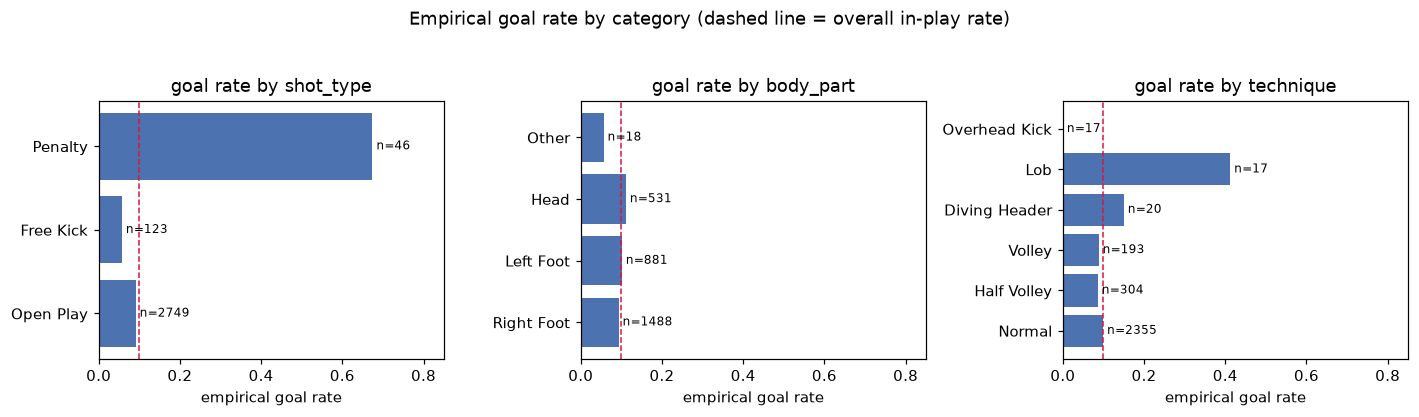

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, column in zip(axes, ("shot_type", "body_part", "technique"), strict=True):
    table = rate_table(in_play, column)
    table = table[table["shots"] >= 15]
    ax.barh(table.index.astype(str), table["goal_rate"], color="#4C72B0")
    ax.axvline(in_play["is_goal"].mean(), color="crimson", linestyle="--", linewidth=1)
    ax.set_title(f"goal rate by {column}")
    ax.set_xlabel("empirical goal rate")
    for position, (_name, row) in enumerate(table.iterrows()):
        ax.text(
            row["goal_rate"] + 0.01, position, f"n={int(row['shots'])}", va="center", fontsize=8
        )
    ax.set_xlim(0, max(0.85, table["goal_rate"].max() * 1.25))
fig.suptitle("Empirical goal rate by category (dashed line = overall in-play rate)", y=1.04)
fig.tight_layout()
plt.show()

**Learned.**

- **Shot type.** Open play dominates: 2,749 shots (94.2%) at a 9.1% goal rate.
  In-play penalties are only 46 shots but convert at **67.4%**; direct free kicks
  are 123 shots at 5.7%.
- **Body part.** Right foot 51.0% of shots (9.3% goal rate), left foot 30.2%
  (10.1%), head 18.2% (**11.1%**). Headers therefore have the *highest* marginal
  conversion of the three — which is emphatically **not** evidence that heading is
  the best way to score, because headers are taken much closer to goal. This is a
  confounded marginal comparison and a good illustration of why §13's spatial view
  matters.
- **Technique.** `Normal` covers 80.7%. The exotic categories are tiny and their
  rates are unusable: `Lob` shows 41.2% on 17 shots, `Overhead Kick` 0% on 17.
- **Play pattern.** Regular play 36.5%, from free kick 18.6%, from corner 16.7%,
  from throw-in 16.7%. The `Other` pattern (54 shots, 61.1%) is essentially the
  penalty bucket.

**Implication.** Several categories are very sparse. Rare technique levels need
grouping or a model that handles them natively (CatBoost, T20); one-hot encoding a
17-shot level invites overfitting. Penalties should be flagged or modelled
separately — 46 observations at a 67% base rate will otherwise distort a model that
mostly sees 10% events. The head-vs-foot result is a standing warning that
**marginal goal rates here are confounded by location** and must never be read as
effect estimates.

## 9. Optional boolean fields and how StatsBomb encodes them

**Inspecting:** the context flags. StatsBomb **omits these keys entirely when they
are false**, so "missing" means `False`, not "unknown". Getting this wrong would
either drop most of the data or invent missingness.

In [13]:
flag_columns = ["under_pressure", *SHOT_FLAGS]
flag_summary = pd.DataFrame(
    {
        "true_count": [int(in_play[c].sum()) for c in flag_columns],
        "share_true": [round(float(in_play[c].mean()) * 100, 2) for c in flag_columns],
        "goal_rate_true": [
            round(float(in_play.loc[in_play[c], "is_goal"].mean()), 3) for c in flag_columns
        ],
        "goal_rate_false": [
            round(float(in_play.loc[~in_play[c], "is_goal"].mean()), 3) for c in flag_columns
        ],
    },
    index=flag_columns,
).sort_values("true_count", ascending=False)
flag_summary

,true_count,share_true,goal_rate_true,goal_rate_false
first_time,751,25.74,0.125,0.090
under_pressure,634,21.73,0.066,0.108
aerial_won,258,8.84,0.074,0.101
one_on_one,101,3.46,0.277,0.092
deflected,36,1.23,0.250,0.097
open_goal,32,1.10,0.625,0.093
redirect,8,0.27,0.375,0.098
follows_dribble,3,0.10,0.000,0.099


**Learned.** `first_time` is set on 25.7% of in-play shots and `under_pressure` on
21.7%; the rest are rare (`one_on_one` 101, `deflected` 36, `open_goal` 32,
`redirect` 8, `follows_dribble` 3). The directional differences are sensible:
open goals convert at 62.5% and one-on-ones at 27.7%, while shots under pressure
convert at 6.6% against 10.8% for the rest.

**Implication.** These are booleans with an *implicit false*, so the correct
handling in T05 is `event.get(flag, False)` — never `dropna()`. The rare flags
(`open_goal`, `redirect`, `follows_dribble`) carry so few observations that any
per-flag estimate will have very wide intervals; they are candidates for exclusion
or pooling rather than individual coefficients.

## 10. Missingness

**Inspecting:** which shot fields are genuinely absent, and whether absence is
random or structural.

In [14]:
missing = (
    shots.isna()
    .sum()
    .rename("missing")
    .to_frame()
    .assign(share=lambda d: (d["missing"] / len(shots) * 100).round(2))
)
display(missing[missing["missing"] > 0])

print("freeze_frame availability by shot type:")
display(pd.crosstab(shots["shot_type"], shots["has_freeze_frame"], margins=True))

,missing,share
end_z,979,32.69


freeze_frame availability by shot type:


has_freeze_frame,False,True,All
shot_type,,,
Free Kick,0,123,123
Open Play,0,2749,2749
Penalty,108,15,123
All,108,2887,2995


**Learned.** Only one column is missing at all: `end_z`, absent for 32.7% of shots
because the shot ended on the ground and `end_location` has two elements instead
of three. That is structural, not a defect. Every shot has a location, an outcome,
a body part, a technique, a player and an xG value.

The important result is the crosstab: **every one of the 108 shots without a
`freeze_frame` is a penalty** (108 of the 123 penalties; open-play and free-kick
shots have 100% coverage). Freeze frames are not missing at random — they are
missing by design for the one shot type whose defensive configuration is fixed by
the laws of the game.

**Implication.** Any feature derived from `freeze_frame` (defender counts, goalkeeper
position, T45-style spatial features) will be systematically unavailable for
penalties. Imputing "0 defenders" there would be a silent fabrication that also
correlates strongly with the target, since penalties convert at 76%. The clean
handling is to exclude penalties from freeze-frame features, or model them
separately.

## 11. Pitch coordinates — verified, not assumed

**Inspecting:** the coordinate system. The claims below come from the official
*StatsBomb Open Data Specification v1.1*, Appendix 2 (Locations), and each is then
checked against our data.

Documented by StatsBomb:

| Element | Coordinates |
| --- | --- |
| Pitch extent | x ∈ [0, 120], y ∈ [0, 80] |
| Centre spot | (60, 40) |
| Goal posts (right) | (120, 36) and (120, 44) |
| Crossbar height | 2.67 |
| Penalty spot (right) | (108, 40) |
| Penalty area (right) | x ≥ 102, 18 ≤ y ≤ 62 |
| Six-yard box (right) | x ≥ 114, 30 ≤ y ≤ 50 |

Units are yards. In StatsBomb's own diagram y = 0 is the *top* touchline, so plots
below invert the y axis to match their figure.

In [15]:
print("observed extent over every located event:")
print(
    f"  x ∈ [{coordinate_extremes['x_min']}, {coordinate_extremes['x_max']}]  "
    f"y ∈ [{coordinate_extremes['y_min']}, {coordinate_extremes['y_max']}]"
)
print("\nobserved extent over shots:")
print(
    f"  x ∈ [{shots['x'].min()}, {shots['x'].max()}]  y ∈ [{shots['y'].min()}, {shots['y'].max()}]"
)

goal_ends = shots.loc[shots["is_goal"], ["end_x", "end_y", "end_z"]]
print("\nend_location of shots that were goals (should sit in the goal mouth):")
print(f"  end_x ∈ [{goal_ends['end_x'].min()}, {goal_ends['end_x'].max()}]")
print(f"  end_y ∈ [{goal_ends['end_y'].min()}, {goal_ends['end_y'].max()}]")
print("      documented posts: y = 36 and y = 44")
print(f"  end_z ∈ [{goal_ends['end_z'].min()}, {goal_ends['end_z'].max()}]")
print("      documented crossbar height: z = 2.67")

observed extent over every located event:
  x ∈ [0.1, 120.0]  y ∈ [0.1, 80.0]

observed extent over shots:
  x ∈ [59.0, 119.4]  y ∈ [8.7, 71.9]

end_location of shots that were goals (should sit in the goal mouth):
  end_x ∈ [119.0, 120.0]
  end_y ∈ [36.2, 44.0]
      documented posts: y = 36 and y = 44
  end_z ∈ [0.0, 2.5]
      documented crossbar height: z = 2.67


**Learned.** Located events span exactly x ∈ [0.1, 120.0] and y ∈ [0.1, 80.0],
consistent with the documented 120 × 80 pitch. Every goal's `end_y` falls inside
[36.2, 44.0] — the documented posts are 36 and 44 — `end_x` is 119.0–120.0, and
`end_z` peaks at 2.5, just under the documented 2.67 crossbar. The data reproduces
the documented goal mouth almost exactly, which independently confirms both the
goal geometry and that x = 120 is the goal being attacked.

In [16]:
direction = (
    in_play.groupby(["team", "period"])["x"]
    .agg(["size", "mean"])
    .rename(columns={"size": "shots", "mean": "mean_x"})
    .round(1)
)
print("mean shot x by team and period (first 6 teams):")
display(direction.head(12))

own_half = in_play[in_play["x"] < 60]
print(f"shots taken from the team's own half (x < 60): {len(own_half)} of {len(in_play)}")
print("\nmean shot x per period across all teams:")
print(in_play.groupby("period")["x"].mean().round(2).to_dict())

mean shot x by team and period (first 6 teams):


shots  mean_x
team      period               
Argentina 1          21   103.3
          2          37   104.5
Australia 1          16   105.3
          2          18   105.2
Austria   1          20   104.9
          2          26   102.5
          3           1   103.8
          4           6   107.2
Belgium   1          83   104.2
          2          73   105.2
Brazil    1          37   104.5
          2          66   105.3

shots taken from the team's own half (x < 60): 1 of 2918

mean shot x per period across all teams:
{1: 103.82, 2: 104.25, 3: 105.23, 4: 105.07}


**Learned — attacking direction is normalised.** Every team's mean shot x is ~100–107
in **both** the first and the second half, and only **one** of 2,918 in-play shots
was taken from x < 60. If coordinates were recorded in true stadium space, teams
would attack x = 120 in one half and x = 0 in the other, and the per-period means
would be mirror images. They are not.

So: **coordinates are recorded from the acting team's perspective, always attacking
toward x = 120**, in every period. This is verified from the data rather than
assumed.

**Implication.** Do **not** flip coordinates by half — a "normalisation" step that
many football datasets require would corrupt this one. Distance and angle (T05)
can be computed against a fixed goal at x = 120, y ∈ [36, 44] for every shot
regardless of team or period.

## 12. Coordinate precision differs between our two competitions

**Inspecting:** the `shot_fidelity_version` / `xy_fidelity_version` match metadata
that the specification (Appendix 10) uses to flag high-precision collection.

In [17]:
fidelity = (
    pd.json_normalize(
        [
            {
                "competition_label": row["competition_label"],
                "shot_fidelity_version": row.get("metadata.shot_fidelity_version"),
                "xy_fidelity_version": row.get("metadata.xy_fidelity_version"),
            }
            for _, row in matches.iterrows()
        ]
    )
    .value_counts(dropna=False)
    .rename("matches")
    .reset_index()
)
display(fidelity)

decimal_share = (
    in_play.assign(has_decimal=lambda d: (d["x"] % 1 != 0) | (d["y"] % 1 != 0))
    .groupby("competition_label")["has_decimal"]
    .agg(shots="size", decimal_coordinates="sum", share="mean")
)
decimal_share["share"] = (decimal_share["share"] * 100).round(1)
display(decimal_share)

,competition_label,shot_fidelity_version,xy_fidelity_version,matches
0,FIFA World Cup 2018,NaN,NaN,64
1,UEFA Euro 2020,2,2,51


,shots,decimal_coordinates,share
competition_label,,,
FIFA World Cup 2018,1667,0,0.0
UEFA Euro 2020,1251,1227,98.1


**Learned — a real heterogeneity in our subset.** World Cup 2018 matches carry no
fidelity metadata and **0 of their 1,667 in-play shot coordinates have a decimal
part**. Euro 2020 matches declare `shot_fidelity_version = 2` and **98.1% of their
1,251 shot coordinates are sub-unit**. The two competitions were collected at
different spatial granularity: roughly 1-yard rounding versus sub-yard precision.

**Implication for feature engineering and validation.** Any geometric feature
(T05 distance, angle) inherits this: the World Cup half of the data has
measurement error of up to ±0.5 yards baked in, the Euro half does not. Because
precision is perfectly confounded with competition, a model can exploit the
*rounding pattern itself* as a competition fingerprint. Two consequences:

1. When evaluating across competitions (a natural held-out split), differences in
   performance may reflect measurement precision, not football.
2. Comparing coefficient estimates between competitions conflates a real effect
   with a measurement-error difference — classic attenuation bias in the
   lower-precision half.

Worth stating explicitly in T05 and revisiting in T15 when the validation strategy
is chosen.

## 13. Where shots are taken

**Inspecting:** the spatial distribution of shots and goals. Only raw coordinates
are used — no derived distance.

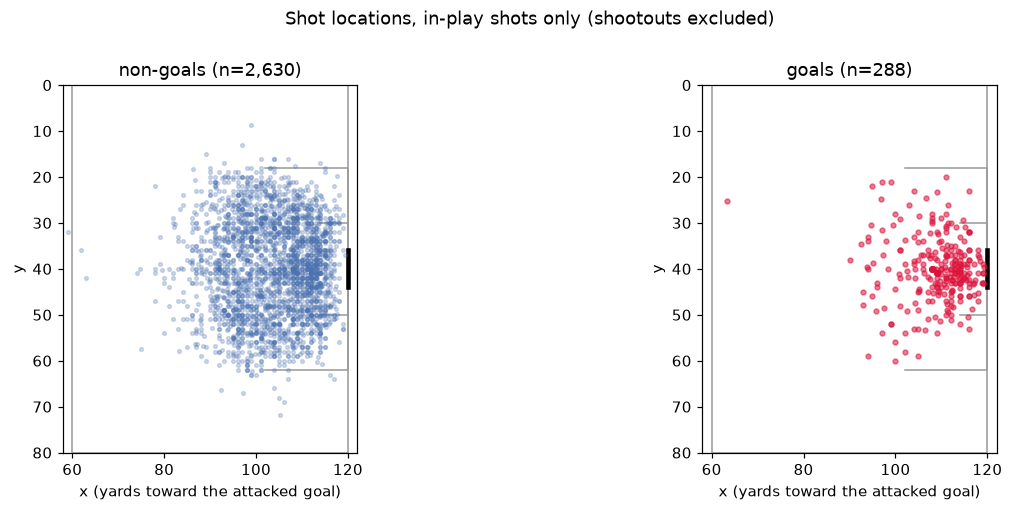

In [18]:
PITCH_LENGTH, PITCH_WIDTH = 120.0, 80.0
GOAL_POSTS = (36.0, 44.0)


def draw_attacking_third(ax: Axes) -> Axes:
    """Draw StatsBomb pitch markings for the attacking half (x from 60 to 120)."""
    line = {"color": "#999999", "linewidth": 1, "zorder": 1}
    ax.plot([60, 120, 120, 60, 60], [0, 0, 80, 80, 0], **line)
    ax.plot([102, 120, 120, 102], [18, 18, 62, 62], **line)  # penalty area
    ax.plot([114, 120, 120, 114], [30, 30, 50, 50], **line)  # six-yard box
    ax.plot([120, 120], list(GOAL_POSTS), color="black", linewidth=3, zorder=2)  # goal mouth
    ax.scatter([108], [40], s=8, color="#999999", zorder=2)  # penalty spot
    ax.set_xlim(58, 122)
    ax.set_ylim(0, 80)
    ax.invert_yaxis()  # StatsBomb draws y = 0 at the top
    ax.set_aspect("equal")
    ax.set_xlabel("x (yards toward the attacked goal)")
    ax.set_ylabel("y")
    return ax


fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
non_goals = in_play[~in_play["is_goal"]]
goals = in_play[in_play["is_goal"]]

draw_attacking_third(axes[0]).set_title(f"non-goals (n={len(non_goals):,})")
axes[0].scatter(non_goals["x"], non_goals["y"], s=6, alpha=0.25, color="#4C72B0", zorder=3)

draw_attacking_third(axes[1]).set_title(f"goals (n={len(goals):,})")
axes[1].scatter(goals["x"], goals["y"], s=10, alpha=0.55, color="crimson", zorder=3)

fig.suptitle("Shot locations, in-play shots only (shootouts excluded)", y=1.0)
fig.tight_layout()
plt.show()

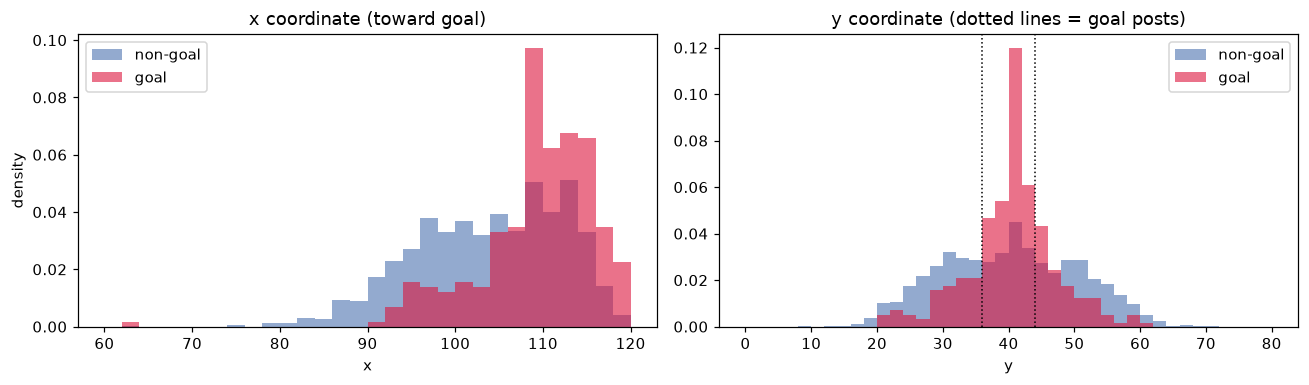

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
bins_x = np.arange(60, 122, 2)
axes[0].hist(
    non_goals["x"], bins=bins_x, density=True, alpha=0.6, label="non-goal", color="#4C72B0"
)
axes[0].hist(goals["x"], bins=bins_x, density=True, alpha=0.6, label="goal", color="crimson")
axes[0].set_title("x coordinate (toward goal)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("density")
axes[0].legend()

bins_y = np.arange(0, 82, 2)
axes[1].hist(
    non_goals["y"], bins=bins_y, density=True, alpha=0.6, label="non-goal", color="#4C72B0"
)
axes[1].hist(goals["y"], bins=bins_y, density=True, alpha=0.6, label="goal", color="crimson")
axes[1].axvline(GOAL_POSTS[0], color="black", linestyle=":", linewidth=1)
axes[1].axvline(GOAL_POSTS[1], color="black", linestyle=":", linewidth=1)
axes[1].set_title("y coordinate (dotted lines = goal posts)")
axes[1].set_xlabel("y")
axes[1].legend()
fig.tight_layout()
plt.show()

**Learned.** Shots concentrate in the penalty area; goals are drawn from a visibly
tighter region, closer to goal and more central. **58.7% of goals are struck from
between the posts (36 ≤ y ≤ 44) against 29.0% of non-goals** — the single clearest
raw signal in the data. The x histogram shows the same separation along the goal
axis, plus a bump in the [108, 110) bin (321 shots against ~200 in its
neighbours), which is the penalty spot at x = 108.

**Implication.** Both coordinates carry clear signal, and the relationship is
plainly **non-linear and non-monotonic in y** (the goal rate peaks at the centre,
y = 40, and falls off in both directions). A linear-in-y logistic regression
cannot express that, which is the motivation for the geometric transform in T05
(distance and angle) and for the GAM smooth terms in T22.

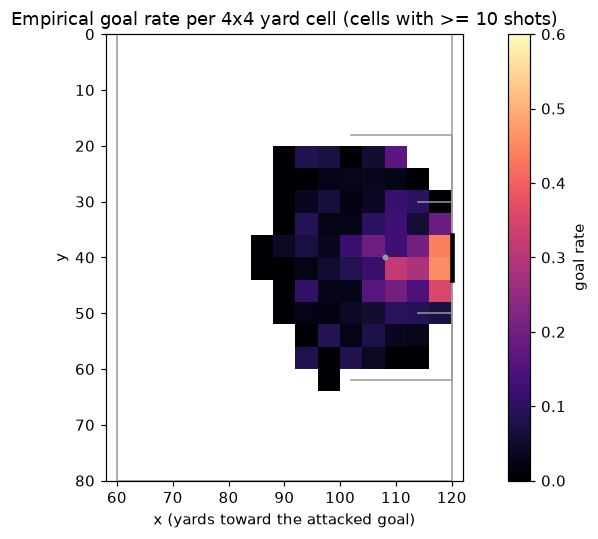

cells with at least 10 shots: 76
cells with any shot at all:       134


In [20]:
X_EDGES = np.arange(60, 124, 4)
Y_EDGES = np.arange(0, 84, 4)

shot_counts, _, _ = np.histogram2d(in_play["x"], in_play["y"], bins=[X_EDGES, Y_EDGES])
goal_counts, _, _ = np.histogram2d(goals["x"], goals["y"], bins=[X_EDGES, Y_EDGES])

MIN_SHOTS = 10
rate = np.where(shot_counts >= MIN_SHOTS, goal_counts / np.maximum(shot_counts, 1), np.nan)

fig, ax = plt.subplots(figsize=(8.5, 5))
mesh = ax.pcolormesh(X_EDGES, Y_EDGES, rate.T, cmap="magma", vmin=0, vmax=0.6, shading="flat")
draw_attacking_third(ax)
ax.set_title(f"Empirical goal rate per 4x4 yard cell (cells with >= {MIN_SHOTS} shots)")
fig.colorbar(mesh, ax=ax, label="goal rate")
fig.tight_layout()
plt.show()

print(f"cells with at least {MIN_SHOTS} shots: {int((shot_counts >= MIN_SHOTS).sum())}")
print(f"cells with any shot at all:       {int((shot_counts > 0).sum())}")

**Learned.** The empirical goal-rate surface rises steeply toward the goal mouth
and is strongly *central*: cells directly in front of goal reach 40–60%, while
cells at the same x but wide of the posts stay near the base rate. Only 76 of the
134 occupied cells clear the 10-shot threshold, so much of the surface is
estimated from very little data.

**Implication.** The signal is genuinely two-dimensional and shaped like an angle
subtended at the goal, not a simple function of x. This is the empirical
justification for the shot-angle feature in T05. The sparsity also shows why a
non-parametric estimate of this surface would be unstable — a smooth parametric or
additive model is more appropriate at this sample size.

## 14. Repeated measures: shots are clustered

**Inspecting:** how shots group by player, match and team. This determines whether
treating shots as independent observations is defensible.

In [21]:
per_player = in_play.groupby("player_id").agg(shots=("is_goal", "size"), goals=("is_goal", "sum"))
per_match = in_play.groupby("match_id").size()
per_team = in_play.groupby("team").size()

print("shots per player:")
print(per_player["shots"].describe().round(2).to_dict())
print(f"  players with a single shot: {int((per_player['shots'] == 1).sum())} of {len(per_player)}")
busiest = per_player["shots"].nlargest(len(per_player) // 20).sum()
print(f"  top 5% of players take {busiest / len(in_play):.1%} of all shots")
print(f"\nshots per match: {per_match.describe().round(2).to_dict()}")
print(f"shots per team: min={per_team.min()} max={per_team.max()}")

print("\nmost shots by a single player:")
display(
    in_play.groupby(["player", "player_id"])
    .agg(shots=("is_goal", "size"), goals=("is_goal", "sum"), goal_rate=("is_goal", "mean"))
    .sort_values("shots", ascending=False)
    .head(8)
    .round(3)
)

shots per player:
{'count': 651.0, 'mean': 4.48, 'std': 4.97, 'min': 1.0, '25%': 1.0, '50%': 3.0, '75%': 5.5, 'max': 37.0}
  players with a single shot: 184 of 651
  top 5% of players take 23.4% of all shots

shots per match: {'count': 115.0, 'mean': 25.37, 'std': 6.55, 'min': 11.0, '25%': 22.0, '50%': 24.0, '75%': 29.0, 'max': 43.0}
shots per team: min=19 max=189

most shots by a single player:


,,shots,goals,goal_rate
player,player_id,,,
Cristiano Ronaldo dos Santos Aveiro,5207,37,9,0.243
Ivan Perišić,5474,31,5,0.161
Harry Kane,10955,30,10,0.333
Emil Peter Forsberg,5625,29,5,0.172
Antoine Griezmann,5487,29,5,0.172
Neymar da Silva Santos Junior,4320,27,2,0.074
Romelu Lukaku Menama,3289,27,8,0.296
Raheem Sterling,3233,25,3,0.120


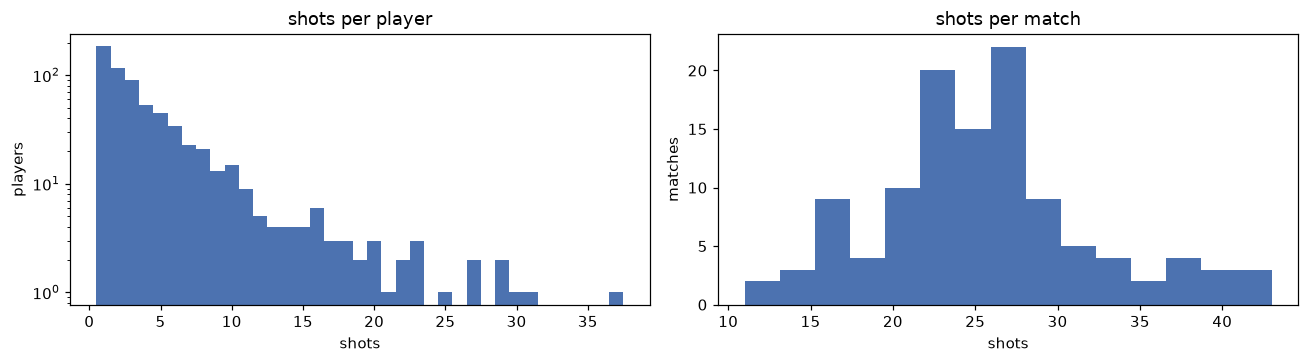

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
axes[0].hist(
    per_player["shots"], bins=np.arange(0.5, per_player["shots"].max() + 1.5), color="#4C72B0"
)
axes[0].set_title("shots per player")
axes[0].set_xlabel("shots")
axes[0].set_ylabel("players")
axes[0].set_yscale("log")

axes[1].hist(per_match, bins=15, color="#4C72B0")
axes[1].set_title("shots per match")
axes[1].set_xlabel("shots")
axes[1].set_ylabel("matches")
fig.tight_layout()
plt.show()

**Learned.** 651 players take at least one in-play shot. The distribution is
severely right-skewed: the median player takes 3, **184 take exactly one**, and the
busiest (Cristiano Ronaldo, 37 shots) accounts for as many as a dozen median
players combined. The top 5% of shooters take 23.4% of all shots. Matches
contribute 11–43 shots each, a mean of 25.4.

**Implication — this is the leakage-relevant finding.**

1. Shots are nested in players, matches and teams, so they are **not iid**.
   Standard errors and confidence intervals computed under independence will be
   too narrow (T20-era statistics tasks, T27).
2. A random shot-level train/test split puts shots from the *same match* on both
   sides, which is optimistic. T15 must use `GroupKFold` by match, and grouping by
   player should be compared against it.
3. Bootstrap resampling must resample **clusters** (matches or players), not
   individual shots (T09).
4. With a median of 3 shots per player, per-player finishing estimates are
   dominated by noise — the direct motivation for partial pooling in T28/T29 and
   for multiple-testing control in T11 when hundreds of players are compared.

## 15. `statsbomb_xg` is a model output, not a feature

**Inspecting:** the `shot.statsbomb_xg` field, which is present on every shot.

In [23]:
print(f"shots carrying statsbomb_xg: {shots['statsbomb_xg'].notna().sum()} of {len(shots)}")
print(in_play["statsbomb_xg"].describe().round(4).to_dict())

calibration = (
    in_play.assign(bucket=pd.cut(in_play["statsbomb_xg"], [0, 0.05, 0.1, 0.2, 0.4, 0.7, 1.0]))
    .groupby("bucket", observed=True)
    .agg(
        shots=("is_goal", "size"),
        observed_rate=("is_goal", "mean"),
        mean_xg=("statsbomb_xg", "mean"),
    )
    .round(3)
)
display(calibration)
print(f"sum of statsbomb_xg over in-play shots: {in_play['statsbomb_xg'].sum():.1f}")
print(f"actual in-play shot goals:              {int(in_play['is_goal'].sum())}")

shots carrying statsbomb_xg: 2995 of 2995
{'count': 2918.0, 'mean': 0.1049, 'std': 0.1467, 'min': 0.003, '25%': 0.0292, '50%': 0.0575, '75%': 0.1099, 'max': 0.9912}


,shots,observed_rate,mean_xg
bucket,,,
"(0.0, 0.05]",1281,0.029,0.026
"(0.05, 0.1]",807,0.053,0.071
"(0.1, 0.2]",483,0.130,0.138
"(0.2, 0.4]",206,0.296,0.275
"(0.4, 0.7]",72,0.444,0.503
"(0.7, 1.0]",69,0.754,0.806


sum of statsbomb_xg over in-play shots: 306.1
actual in-play shot goals:              288


**Learned.** Every shot carries `statsbomb_xg`, StatsBomb's own expected-goals
estimate (median 0.058, mean 0.105). It tracks observed frequencies closely across
buckets, though it sits slightly high in most of them: the total over in-play shots
is **306.1 against 288 actual goals**, a 6.3% over-prediction. On 288 events the
Poisson standard error is about ±17, so that gap is roughly one standard
deviation — consistent with sampling noise rather than demonstrated miscalibration.
Judging a model's calibration on 115 matches is itself a small-sample exercise.

**Implication — leakage trap.** This field is *the output of a model trained to
predict our target*, computed with information we do not otherwise use (including
the freeze frame and proprietary features). Using it as a predictor would produce
excellent metrics that mean nothing: we would be measuring how well we can copy
StatsBomb's model, not how well we model goals. It must be excluded from the
feature set in T05.

It is however an excellent **benchmark**: a project-built xG model that cannot
approach this log loss has room to improve, and the comparison is a natural part
of T16/T21. Keep the column, label it clearly, never train on it.

## 16. Own goals and score reconciliation

**Inspecting:** whether goals derived from shot events reconcile with the recorded
match scores — a direct data-quality check on our extraction.

In [24]:
print(f"own goal events in the stream: {dict(own_goal_events)}")

shot_goals_in_play = int(in_play["is_goal"].sum())
own_goals = own_goal_events["Own Goal Against"]
recorded = int((matches["home_score"] + matches["away_score"]).sum())

print(f"\ngoals from non-shootout shots: {shot_goals_in_play}")
print(f"own goals:                     {own_goals}")
print(f"total:                         {shot_goals_in_play + own_goals}")
print(f"sum of recorded match scores:  {recorded}")
print(f"reconciles: {shot_goals_in_play + own_goals == recorded}")

own goal events in the stream: {'Own Goal For': 23, 'Own Goal Against': 23}

goals from non-shootout shots: 288
own goals:                     23
total:                         311
sum of recorded match scores:  311
reconciles: True


**Learned.** The reconciliation is exact: 288 goals from in-play shots plus 23 own
goals equals the 311 goals recorded in match metadata. Own goals are logged as
`Own Goal Against` / `Own Goal For` events, **not** as shots, and shootout goals
correctly do not count toward the score.

**Implication.** Our shot extraction loses nothing and invents nothing. It also
means "goals scored" at team or player level cannot be computed from shot events
alone — own goals must be added, and shootout goals excluded. Any T04 aggregation
or T31 finishing metric that ignores this will disagree with the official record.

## 17. Conclusions

### Dataset adequacy

The subset is **adequate for this task and for the modelling tasks that follow**,
with a known limit. After excluding shootouts there are **2,918 shots and 288
goals (9.87%)** across 115 matches, 44 teams and 651 shooters. That supports EDA,
hypothesis testing and a logistic baseline comfortably, and boosting models
modestly. No change to the acquisition configuration is needed for T03.

The binding constraint is **shots per player** (median 3), which limits
player-level inference. If T29–T31 need richer within-player data, the smallest
justified change is to add one club season — the acquisition layer already
supports it (`make data DATA_ARGS="--competition-season 11/27"`). That decision
belongs to those tasks, not this one.

### Findings that change what we do next

| # | Finding | Affects |
| --- | --- | --- |
| 1 | Coordinates are normalised so the acting team always attacks toward x = 120, in every period (verified: 1 of 2,918 shots from x < 60) | T05 — do **not** flip by half; goal is fixed at x = 120 |
| 2 | Period 5 = penalty shootouts, 77 shots at a 64.9% conversion rate | T05/T31 — exclude; they are a different process and not part of the score |
| 3 | `statsbomb_xg` is present on every shot and is a model output | T05/T14 — exclude as a feature, keep as a benchmark |
| 4 | Shots are clustered in players, matches and teams; median 3 shots per player | T09/T15/T27–T31 — grouped CV, clustered bootstrap, partial pooling |
| 5 | Coordinate precision differs by competition (WC 2018 integer, Euro 2020 sub-yard) | T05/T15 — measurement error confounded with competition |
| 6 | Optional booleans are omitted when false | T05 — `get(flag, False)`, never `dropna()` |
| 7 | Every shot missing a `freeze_frame` is a penalty (structural, not random) | T45 — no imputation; exclude or model penalties separately |
| 8 | Goal rate is non-monotonic in y and peaks centrally | T05/T22 — geometric transform and smooth terms, not linear-in-y |
| 9 | Own goals are separate events; shot goals + own goals reconcile exactly to the score | T04/T31 — aggregate goals from both sources |
| 10 | In-play penalties (46) convert at 67.4% vs a 9.9% base rate | T05/T14 — flag or model separately |

### Limitations of this notebook

- Two men's international tournaments only; nothing here generalises to league or
  women's football without re-checking.
- All goal rates shown are **marginal and confounded** — notably the head/foot
  comparison, which is contaminated by location. They describe the data, they do
  not estimate effects.
- Cell-level goal rates in §13 rest on small counts; only cells with ≥10 shots are
  shown and even those are noisy.
- Geometry (distance, angle) is deliberately absent and belongs to T05.